---
---

Setup & Imports

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import pandas
from datetime import datetime
now = datetime.now()

In [2]:
# Get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')
CDR = os.environ["WORKSPACE_CDR"]
prefix = f'{my_bucket}/data/dfs/'

print(f"Bucket: {my_bucket}")
print(f"CDR: {CDR}")

Bucket: gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da
CDR: fc-aou-cdr-prod.R2022Q4R13


### Set Seeds for Reproducibility

In [3]:
def set_seeds(offset=0):
    import os
    import random
    import numpy as np
    import tensorflow as tf

    # Set the seed for numpy
    np.random.seed(42+offset)

    # Set the seed for the Python random module
    random.seed(42+offset)

    # Set the seed for TensorFlow
    tf.random.set_seed(42+offset)

    # Ensure reproducibility with certain environment variables
    os.environ['PYTHONHASHSEED'] = str(42+offset)


set_seeds()

2026-02-17 17:45:44.401458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-17 17:45:45.127559: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-17 17:45:45.253843: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-17 17:45:46.689448: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


----

Create function to start/stop logging RAM usage to file

----

In [4]:
import os
import psutil
import threading
import time
from google.cloud import storage

def log_memory_usage(stop_event, file_name):
    with open(file_name, 'w') as f:
        while not stop_event.is_set():
            # Log memory usage to a local file
            memory_info = psutil.virtual_memory()
            gb_used = memory_info.used / (1024 ** 3)
            mem_usage = f"{time.ctime()}: {gb_used:.2f} GB\n"
            print(mem_usage)
            f.write(mem_usage)
            f.flush()
            
            # Upload the local file to GCS
            try:
                destination_blob_name = f'logs/{file_name}'
                upload_to_gcs(file_name, destination_blob_name)
            except Exception as e:
                print(f"Failed to upload to GCS: {e}")
                
            time.sleep(30)
            
def upload_to_gcs(source_file_name, destination_blob_name):
    """Uploads a file to the bucket."""
    # Get the bucket name
    my_bucket = os.getenv('WORKSPACE_BUCKET')
    # Initialize a storage client
    storage_client = storage.Client()
    bucket = storage_client.bucket(my_bucket[5:])
    blob = bucket.blob(destination_blob_name)

    # Upload the file
    blob.upload_from_filename(source_file_name)

#     print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [5]:
stop_event = threading.Event()
memory_thread = None
thread_lock = threading.Lock()  # To ensure thread-safe operations

def RAM_start():
    global stop_event
    global memory_thread

    with thread_lock:
        # Clear the stop event if it is set
        if stop_event.is_set():
            stop_event.clear()

        file_name = 'memory_usage.txt'
        
        # Stop the existing thread if it is running
        if memory_thread and memory_thread.is_alive():
            RAM_stop()
        
        # Create and start a new memory logging thread
        memory_thread = threading.Thread(target=log_memory_usage, args=(stop_event, file_name))
        memory_thread.start()
        print("Memory logging started")

def RAM_stop():
    global stop_event
    global memory_thread

    with thread_lock:
        # Set the stop event to signal the thread to stop
        stop_event.set()

        # Wait for the thread to finish if it exists
        if memory_thread:
            memory_thread.join()
            memory_thread = None  # Reset the thread to None
            print("Memory logging stopped")

In [ ]:
RAM_start()

---

### Load Saved Datasets from Prior Notebooks

In [7]:
# Copy files from GCS to local
!gsutil cp {my_bucket}/data/dfs/daily_df_v2.csv daily_df_v2.csv
!gsutil cp {my_bucket}/data/dfs/daily_df_v2_prepped.csv daily_df_v2_prepped.csv
!gsutil cp {my_bucket}/data/dfs/daily_df_labels_v2.csv daily_df_labels_v2.csv
!gsutil cp {my_bucket}/data/dfs/demographics_df.csv demographics_df.csv

Copying gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/dfs/daily_df_v2.csv...
| [1 files][  3.1 GiB/  3.1 GiB]   59.1 MiB/s                                   
Operation completed over 1 objects/3.1 GiB.                                      
Copying gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/dfs/daily_df_v2_prepped.csv...
| [1 files][  2.5 GiB/  2.5 GiB]   53.3 MiB/s                                   
Operation completed over 1 objects/2.5 GiB.                                      
Copying gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/dfs/daily_df_labels_v2.csv...
/ [1 files][189.2 KiB/189.2 KiB]                                                
Operation completed over 1 objects/189.2 KiB.                                    
Copying gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/dfs/demographics_df.csv...
/ [1 files][875.7 KiB/875.7 KiB]                                                
Operation completed over 1 objects/875.7 KiB.              

In [8]:
# Read saved CSVs
daily_df_raw = pd.read_csv("daily_df_v2.csv")
daily_df_prepped = pd.read_csv("daily_df_v2_prepped.csv")
labels = pd.read_csv("daily_df_labels_v2.csv", index_col=0)
demo_df_saved = pd.read_csv("demographics_df.csv")

print(f"daily_df_raw:     {daily_df_raw.shape[0]:>10,} rows, {daily_df_raw['person_id'].nunique():>6,} unique persons")
print(f"daily_df_prepped: {daily_df_prepped.shape[0]:>10,} rows, {daily_df_prepped['person_id'].nunique():>6,} unique persons")
print(f"labels:           {labels.shape[0]:>10,} persons")
print(f"demo_df_saved:    {demo_df_saved.shape[0]:>10,} persons")

daily_df_raw:     11,446,253 rows, 13,779 unique persons
daily_df_prepped: 10,009,942 rows, 13,779 unique persons
labels:               13,835 persons
demo_df_saved:        15,589 persons


### Helper: Query BigQuery

In [9]:
def load_ids_from_gbq(sql_query):
    """Execute a query and return a set of person_ids."""
    df = pd.read_gbq(
        sql_query,
        dialect="standard",
        use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
        progress_bar_type="tqdm_notebook")
    return set(df['person_id'].unique())

def load_df_from_gbq(sql_query):
    """Execute a query and return a DataFrame."""
    return pd.read_gbq(
        sql_query,
        dialect="standard",
        use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
        progress_bar_type="tqdm_notebook")

---
---

# Re-Query Per-Domain Person ID Lists

We need to reconstruct **who was available** in each data domain (activity, sleep, heart rate, demographics) for each cohort (anxiety, depression, no disorder) **before** the intersection filter was applied in Notebook 1.

Since the intermediate CSVs are no longer available, we re-query BigQuery for `DISTINCT person_id` only — this is much cheaper than pulling full feature data.

## Define Cohort Concept IDs


In [10]:
# Cohort definitions (same as NB1)
cohorts = {
    'anxiety': 442077,
    'depression': 440383,
    'not_anxiety_depression': [440383, 442077]
}

## Define Cohort Filter SQL Fragment


In [12]:
def get_cohort_filter_sql(cohort, concept_ids):
    """Generate the cohort-specific WHERE clause fragment."""
    if cohort.startswith('not_'):
        in_or_not = "AND cb_search_person.person_id NOT IN ("
    else:
        in_or_not = "AND cb_search_person.person_id IN ("

    if isinstance(concept_ids, list):
        concept_condition = ", ".join([str(cid) for cid in concept_ids])
    else:
        concept_condition = str(concept_ids)

    return f"""
        SELECT DISTINCT person_id
        FROM `{CDR}.cb_search_person` cb_search_person
        WHERE cb_search_person.person_id IN (
            SELECT person_id
            FROM `{CDR}.cb_search_person` p
            WHERE has_fitbit = 1
        )
        {in_or_not}
            SELECT criteria.person_id
            FROM (
                SELECT DISTINCT person_id, entry_date, concept_id
                FROM `{CDR}.cb_search_all_events`
                WHERE (concept_id IN (
                    SELECT DISTINCT c.concept_id
                    FROM `{CDR}.cb_criteria` c
                    JOIN (
                        SELECT CAST(cr.id as string) AS id
                        FROM `{CDR}.cb_criteria` cr
                        WHERE concept_id IN ({concept_condition})
                        AND full_text LIKE '%_rank1]%'
                    ) a ON (
                        c.path LIKE CONCAT('%.', a.id, '.%')
                        OR c.path LIKE CONCAT('%.', a.id)
                        OR c.path LIKE CONCAT(a.id, '.%')
                        OR c.path = a.id
                    )
                    WHERE is_standard = 1 AND is_selectable = 1
                ) AND is_standard = 1)
            ) criteria
        )
    """

## Build Per-Domain Queries (DISTINCT person_id Only)


In [14]:
def build_domain_id_queries(cohort, concept_ids):
    """Build lightweight DISTINCT person_id queries for each data domain."""
    cohort_filter = get_cohort_filter_sql(cohort, concept_ids)

    queries = {}

    # Activity
    queries['activity'] = f"""
        SELECT DISTINCT activity_summary.person_id
        FROM `{CDR}.activity_summary` activity_summary
        WHERE activity_summary.person_id IN ({cohort_filter})
    """

    # Sleep
    queries['sleep'] = f"""
        SELECT DISTINCT sleep_daily_summary.person_id
        FROM `{CDR}.sleep_daily_summary` sleep_daily_summary
        WHERE sleep_daily_summary.person_id IN ({cohort_filter})
    """

    # Heart Rate (minute-level — this is the most expensive query)
    queries['heart_rate'] = f"""
        SELECT DISTINCT heart_rate_minute_level.person_id
        FROM `{CDR}.heart_rate_minute_level` heart_rate_minute_level
        WHERE heart_rate_minute_level.person_id IN ({cohort_filter})
    """

    # Demographics (person table — everyone in cohort has a person record)
    queries['demographics'] = f"""
        SELECT DISTINCT person.person_id
        FROM `{CDR}.person` person
        WHERE person.person_id IN ({cohort_filter})
    """

    return queries

## Execute All 12 Domain × Cohort Queries

**Note:** The heart rate minute-level queries scan a large table. This section may take several minutes per cohort.

In [15]:
# Execute all 12 queries
ids = {}

for cohort_name, concept_ids in cohorts.items():
    print(f"\n{'='*60}")
    print(f"Querying cohort: {cohort_name}")
    print(f"{'='*60}")

    queries = build_domain_id_queries(cohort_name, concept_ids)
    ids[cohort_name] = {}

    for domain, sql in queries.items():
        print(f"  Querying {domain}...", end=" ", flush=True)
        ids[cohort_name][domain] = load_ids_from_gbq(sql)
        print(f"found {len(ids[cohort_name][domain]):,} person_ids")

print("\nAll 12 domain × cohort queries complete.")


Querying cohort: anxiety
  Querying activity... 

Downloading:   0%|          | 0/2541 [00:00<?, ?rows/s]

found 2,541 person_ids
  Querying sleep... 

Downloading:   0%|          | 0/2469 [00:00<?, ?rows/s]

found 2,469 person_ids
  Querying heart_rate... 

...

found 11,663 person_ids
  Querying heart_rate... 

Downloading:   0%|          | 0/11083 [00:00<?, ?rows/s]

found 11,083 person_ids
  Querying demographics... 

Downloading:   0%|          | 0/12245 [00:00<?, ?rows/s]

found 12,245 person_ids

All 12 domain × cohort queries complete.


## Query the Full Fitbit Universe (All person_ids with has_fitbit = 1)

In [16]:
sql_fitbit_universe = f"""
    SELECT DISTINCT person_id
    FROM `{CDR}.cb_search_person`
    WHERE person_id IN (
        SELECT person_id
        FROM `{CDR}.cb_search_person`
        WHERE has_fitbit = 1
    )
"""

print("Querying full Fitbit universe...")
fitbit_universe_ids = load_ids_from_gbq(sql_fitbit_universe)
print(f"Total Fitbit universe: {len(fitbit_universe_ids):,} person_ids")

Querying full Fitbit universe...


Downloading:   0%|          | 0/15589 [00:00<?, ?rows/s]

Total Fitbit universe: 15,589 person_ids


## Query Full Demographics for ALL Fitbit Participants


In [49]:
sql_all_fitbit_demographics = f"""
    SELECT
        person.person_id,
        p_gender_concept.concept_name as gender,
        person.birth_datetime as date_of_birth,
        p_race_concept.concept_name as race,
        p_ethnicity_concept.concept_name as ethnicity,
        p_sex_at_birth_concept.concept_name as sex_at_birth
    FROM `{CDR}.person` person
    LEFT JOIN `{CDR}.concept` p_gender_concept
        ON person.gender_concept_id = p_gender_concept.concept_id
    LEFT JOIN `{CDR}.concept` p_race_concept
        ON person.race_concept_id = p_race_concept.concept_id
    LEFT JOIN `{CDR}.concept` p_ethnicity_concept
        ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id
    LEFT JOIN `{CDR}.concept` p_sex_at_birth_concept
        ON person.sex_at_birth_concept_id = p_sex_at_birth_concept.concept_id
    WHERE person.person_id IN (
        SELECT person_id
        FROM `{CDR}.cb_search_person`
        WHERE has_fitbit = 1
    )
"""

print("Querying demographics for full Fitbit population...")
all_fitbit_demo = load_df_from_gbq(sql_all_fitbit_demographics)

# Calculate age
all_fitbit_demo['date_of_birth'] = pd.to_datetime(all_fitbit_demo['date_of_birth'])
all_fitbit_demo['age'] = all_fitbit_demo['date_of_birth'].apply(
    lambda born: datetime.now().year - born.year - ((datetime.now().month, datetime.now().day) < (born.month, born.day))
)
all_fitbit_demo = all_fitbit_demo.drop(columns=['date_of_birth'])

print(f"Demographics retrieved for {len(all_fitbit_demo):,} Fitbit participants")

Querying demographics for full Fitbit population...
Demographics retrieved for 15,589 Fitbit participants


## Summary of Re-Queried Counts


In [18]:
print(f"{'Cohort':<30} {'Activity':>10} {'Sleep':>10} {'Heart Rate':>10} {'Demographics':>12}")
print("-" * 82)
for cohort_name in cohorts:
    print(f"{cohort_name:<30} "
          f"{len(ids[cohort_name]['activity']):>10,} "
          f"{len(ids[cohort_name]['sleep']):>10,} "
          f"{len(ids[cohort_name]['heart_rate']):>10,} "
          f"{len(ids[cohort_name]['demographics']):>12,}")
print("-" * 82)
print(f"{'Fitbit Universe':<30} {len(fitbit_universe_ids):>10,}")

Cohort                           Activity      Sleep Heart Rate Demographics
----------------------------------------------------------------------------------
anxiety                             2,541      2,469      2,345        2,556
depression                          2,403      2,338      2,213        2,415
not_anxiety_depression             12,194     11,663     11,083       12,245
----------------------------------------------------------------------------------
Fitbit Universe                    15,589


---
---

# Reconstruct Exclusion Counts at Each Stage

The data pipeline involves 5 sequential exclusion stages:

| Stage | Description | Notebook |
|-------|-------------|----------|
| 0 | All of Us Fitbit users | — |
| 1 | Cohort diagnosis filter | NB1 |
| 2 | Intersection across data domains (sleep ∩ activity ∩ HR ∩ demographics) | NB1 Cell 73 |
| 3 | Inner merge on date (sleep ⟕ activity ⟕ HR) | NB1 Cell 109 |
| 4 | Data preparation (nap removal, column drops) | NB2 |
| 5 | 10-day contiguous chunk with no NaN in HR columns (others provided ^^) | NB3 Cell 14 |

## Stage 0: Fitbit Universe


In [19]:
n_stage0 = len(fitbit_universe_ids)
print(f"Stage 0 — All of Us participants with Fitbit data: {n_stage0:,}")

Stage 0 — All of Us participants with Fitbit data: 15,589


## Stage 1: Cohort Diagnosis Filter

In [20]:
# Union of all person_ids across domains for each cohort
# (represents everyone who appears in at least one domain for that cohort)
cohort_union_ids = {}
for cohort_name in cohorts:
    cohort_union_ids[cohort_name] = (
        ids[cohort_name]['activity'] |
        ids[cohort_name]['sleep'] |
        ids[cohort_name]['heart_rate'] |
        ids[cohort_name]['demographics']
    )

n_stage1_by_cohort = {c: len(v) for c, v in cohort_union_ids.items()}

# Total unique across all cohorts (some people may appear in multiple cohorts — anxiety+depression overlap)
all_cohort_ids = set()
for v in cohort_union_ids.values():
    all_cohort_ids |= v

n_stage1 = len(all_cohort_ids)

print(f"Stage 1 — After cohort diagnosis filter:")
for c, n in n_stage1_by_cohort.items():
    print(f"  {c:<30}: {n:>8,}")
print(f"  {'TOTAL unique across cohorts':<30}: {n_stage1:>8,}")
print(f"\n  Excluded from Fitbit universe: {n_stage0 - n_stage1:>8,} ({(n_stage0 - n_stage1)/n_stage0*100:.1f}%)")
print(f"  (These are Fitbit users with no anxiety, no depression, AND no 'no-disorder' flag — ")
print(f"   this count should be ~0 if the no_disorder cohort captures everyone NOT in anxiety/depression)")

Stage 1 — After cohort diagnosis filter:
  anxiety                       :    2,556
  depression                    :    2,415
  not_anxiety_depression        :   12,245
  TOTAL unique across cohorts   :   15,589

  Excluded from Fitbit universe:        0 (0.0%)
  (These are Fitbit users with no anxiety, no depression, AND no 'no-disorder' flag — 
   this count should be ~0 if the no_disorder cohort captures everyone NOT in anxiety/depression)


## Stage 2: Intersection Across Data Domains


In [21]:
# Replicate NB1 Cell 73: intersection across sleep, activity, HR, demographics per cohort
cohort_intersection_ids = {}
for cohort_name in cohorts:
    cohort_intersection_ids[cohort_name] = (
        ids[cohort_name]['activity'] &
        ids[cohort_name]['sleep'] &
        ids[cohort_name]['heart_rate'] &
        ids[cohort_name]['demographics']
    )

n_stage2_by_cohort = {c: len(v) for c, v in cohort_intersection_ids.items()}

all_intersection_ids = set()
for v in cohort_intersection_ids.values():
    all_intersection_ids |= v

n_stage2 = len(all_intersection_ids)

print(f"Stage 2 — After intersection filter (must have data in ALL 4 domains):")
print(f"{'Cohort':<30} {'Before (union)':>15} {'After (intersect)':>18} {'Excluded':>10} {'% Excluded':>12}")
print("-" * 90)
for cohort_name in cohorts:
    n_before = n_stage1_by_cohort[cohort_name]
    n_after = n_stage2_by_cohort[cohort_name]
    n_excl = n_before - n_after
    pct_excl = n_excl / n_before * 100 if n_before > 0 else 0
    print(f"{cohort_name:<30} {n_before:>15,} {n_after:>18,} {n_excl:>10,} {pct_excl:>11.1f}%")

print("-" * 90)
n_excl_total = n_stage1 - n_stage2
print(f"{'TOTAL':<30} {n_stage1:>15,} {n_stage2:>18,} {n_excl_total:>10,} {n_excl_total/n_stage1*100:>11.1f}%")

Stage 2 — After intersection filter (must have data in ALL 4 domains):
Cohort                          Before (union)  After (intersect)   Excluded   % Excluded
------------------------------------------------------------------------------------------
anxiety                                  2,556              2,299        257        10.1%
depression                               2,415              2,176        239         9.9%
not_anxiety_depression                  12,245             10,831      1,414        11.5%
------------------------------------------------------------------------------------------
TOTAL                                   15,589             13,835      1,754        11.3%


### Which domains cause the most exclusion?


In [22]:
# For each cohort, show which domains are missing for excluded people
print("Breakdown of domain availability for EXCLUDED participants at Stage 2:\n")

for cohort_name in cohorts:
    excluded_ids = cohort_union_ids[cohort_name] - cohort_intersection_ids[cohort_name]
    if len(excluded_ids) == 0:
        print(f"{cohort_name}: No exclusions at this stage.")
        continue

    print(f"{cohort_name} — {len(excluded_ids):,} excluded participants:")
    for domain in ['activity', 'sleep', 'heart_rate', 'demographics']:
        has_domain = excluded_ids & ids[cohort_name][domain]
        missing_domain = excluded_ids - ids[cohort_name][domain]
        print(f"  {domain:<15}: {len(has_domain):>8,} have data ({len(has_domain)/len(excluded_ids)*100:5.1f}%), "
              f"{len(missing_domain):>8,} missing ({len(missing_domain)/len(excluded_ids)*100:5.1f}%)")
    print()

Breakdown of domain availability for EXCLUDED participants at Stage 2:

anxiety — 257 excluded participants:
  activity       :      242 have data ( 94.2%),       15 missing (  5.8%)
  sleep          :      170 have data ( 66.1%),       87 missing ( 33.9%)
  heart_rate     :       46 have data ( 17.9%),      211 missing ( 82.1%)
  demographics   :      257 have data (100.0%),        0 missing (  0.0%)

depression — 239 excluded participants:
  activity       :      227 have data ( 95.0%),       12 missing (  5.0%)
  sleep          :      162 have data ( 67.8%),       77 missing ( 32.2%)
  heart_rate     :       37 have data ( 15.5%),      202 missing ( 84.5%)
  demographics   :      239 have data (100.0%),        0 missing (  0.0%)

not_anxiety_depression — 1,414 excluded participants:
  activity       :    1,363 have data ( 96.4%),       51 missing (  3.6%)
  sleep          :      832 have data ( 58.8%),      582 missing ( 41.2%)
  heart_rate     :      252 have data ( 17.8%),    1,16

## Stage 3: Inner Merge on Date

In [23]:
# From the saved daily_df_v2.csv (output of NB1 merge, before NB2 prep)
ids_after_merge = set(daily_df_raw['person_id'].unique())
n_stage3 = len(ids_after_merge)

# People who were in the intersection set but lost during the inner merge on dates
ids_lost_at_merge = all_intersection_ids - ids_after_merge
n_lost_stage3 = len(ids_lost_at_merge)

print(f"Stage 3 — After inner merge on date (sleep ⟕ activity ⟕ HR):")
print(f"  Before (Stage 2 intersection): {n_stage2:>8,}")
print(f"  After merge:                   {n_stage3:>8,}")
print(f"  Excluded:                      {n_lost_stage3:>8,} ({n_lost_stage3/n_stage2*100:.1f}%)")
print(f"\n  (These are people whose recorded dates don't overlap across all 3 data domains)")

Stage 3 — After inner merge on date (sleep ⟕ activity ⟕ HR):
  Before (Stage 2 intersection):   13,835
  After merge:                     13,779
  Excluded:                            56 (0.4%)

  (These are people whose recorded dates don't overlap across all 3 data domains)


## Stage 4: Data Preparation (Nap Removal, Column Drops)


In [24]:
# From the saved daily_df_v2_prepped.csv (output of NB2)
ids_after_prep = set(daily_df_prepped['person_id'].unique())
n_stage4 = len(ids_after_prep)

ids_lost_at_prep = ids_after_merge - ids_after_prep
n_lost_stage4 = len(ids_lost_at_prep)

print(f"Stage 4 — After data preparation (nap removal, column drops):")
print(f"  Before (Stage 3):  {n_stage3:>8,}")
print(f"  After prep:        {n_stage4:>8,}")
print(f"  Excluded:          {n_lost_stage4:>8,} ({n_lost_stage4/n_stage3*100:.1f}%)")
print(f"\n  (Nap-only records removed; minute_restless, elevation, minute_deep/light/rem/wake dropped)")
print(f"  Note: Column drops don't typically remove entire persons — only the is_main_sleep filter might.")

Stage 4 — After data preparation (nap removal, column drops):
  Before (Stage 3):    13,779
  After prep:          13,779
  Excluded:                 0 (0.0%)

  (Nap-only records removed; minute_restless, elevation, minute_deep/light/rem/wake dropped)
  Note: Column drops don't typically remove entire persons — only the is_main_sleep filter might.


## Stage 5: 10-Day Contiguous Chunk Requirement


This is the **stochastic** exclusion step. The function `get_random_chunk` attempts up to 10 times to find a contiguous 10-day window with no NaN in the HR columns (`std_hr`, `morning_hr`, `afternoon_hr`, `evening_hr`, `night_hr`). Participants who fail are silently dropped.

Since this is seed-dependent, we simulate it across all 100 experiment seeds to characterize the variability.

In [25]:
# Replicate the chunk selection functions from NB3 Cell 14

def get_random_chunk(df, chunk_size=10, max_attempts=10):
    """Get a random chunk of contiguous days with no NaNs in HR columns."""
    columns_to_check = ['std_hr', 'morning_hr', 'afternoon_hr', 'evening_hr', 'night_hr']
    df = df.sort_values(by='date').reset_index(drop=True)
    if len(df) < chunk_size:
        return None
    
    attempts = 0
    while attempts < max_attempts:
        start_idx = np.random.randint(0, len(df) - chunk_size + 1)
        chunk = df.iloc[start_idx:start_idx + chunk_size]
        if not chunk[columns_to_check].isna().any().any():
            return chunk
        attempts += 1
    
    return None

def get_random_contiguous_chunks_with_no_missing_data(df, chunk_size=10, max_attempts=10):
    """Apply chunk selection to each person."""
    grouped = df.groupby('person_id')
    chunks = grouped.apply(lambda x: get_random_chunk(x, chunk_size, max_attempts)).dropna()
    chunks.reset_index(drop=True, inplace=True)
    return chunks

In [26]:
# Run Stage 5 simulation across all 100 experiment seeds
print("Simulating Stage 5 chunk selection across 100 seeds...")
print("(This may take several minutes)\n")

stage5_results = []

for offset in range(100):
    set_seeds(offset=offset)
    chunks = get_random_contiguous_chunks_with_no_missing_data(daily_df_prepped, chunk_size=10, max_attempts=10)
    included_ids = set(chunks['person_id'].unique())
    stage5_results.append({
        'seed_offset': offset,
        'n_included': len(included_ids),
        'n_excluded': len(ids_after_prep) - len(included_ids),
        'included_ids': included_ids
    })
    if (offset + 1) % 10 == 0:
        print(f"  Completed seed {offset + 1}/100 — included: {len(included_ids):,}")

stage5_inclusion_counts = [r['n_included'] for r in stage5_results]
stage5_exclusion_counts = [r['n_excluded'] for r in stage5_results]

print(f"\nStage 5 — 10-day contiguous chunk selection (across 100 seeds):")
print(f"  Input (Stage 4):           {n_stage4:>8,}")
print(f"  Included — mean:           {np.mean(stage5_inclusion_counts):>8,.1f}")
print(f"  Included — min:            {np.min(stage5_inclusion_counts):>8,}")
print(f"  Included — max:            {np.max(stage5_inclusion_counts):>8,}")
print(f"  Included — std:            {np.std(stage5_inclusion_counts):>8,.1f}")
print(f"  Excluded — mean:           {np.mean(stage5_exclusion_counts):>8,.1f} ({np.mean(stage5_exclusion_counts)/n_stage4*100:.1f}%)")

Simulating Stage 5 chunk selection across 100 seeds...
(This may take several minutes)

  Completed seed 10/100 — included: 12,404
  Completed seed 20/100 — included: 12,404
  Completed seed 30/100 — included: 12,422
  Completed seed 40/100 — included: 12,427
  Completed seed 50/100 — included: 12,411
  Completed seed 60/100 — included: 12,427
  Completed seed 70/100 — included: 12,416
  Completed seed 80/100 — included: 12,401
  Completed seed 90/100 — included: 12,414
  Completed seed 100/100 — included: 12,402

Stage 5 — 10-day contiguous chunk selection (across 100 seeds):
  Input (Stage 4):             13,779
  Included — mean:           12,405.3
  Included — min:              12,371
  Included — max:              12,443
  Included — std:                13.3
  Excluded — mean:            1,373.7 (10.0%)


In [27]:
# Use seed offset=0 as the representative sample for detailed comparisons
ids_after_chunk_seed0 = stage5_results[0]['included_ids']
n_stage5 = len(ids_after_chunk_seed0)
ids_lost_at_chunk_seed0 = ids_after_prep - ids_after_chunk_seed0

print(f"Using seed_offset=0 as representative:")
print(f"  Included: {n_stage5:,}")
print(f"  Excluded: {len(ids_lost_at_chunk_seed0):,} ({len(ids_lost_at_chunk_seed0)/n_stage4*100:.1f}%)")

Using seed_offset=0 as representative:
  Included: 12,420
  Excluded: 1,359 (9.9%)


## Overall Exclusion Summary Table

In [28]:
# Build summary table
flow_data = [
    {'Stage': 0, 'Description': 'All of Us Fitbit users',
     'N_In': n_stage0, 'N_Out': n_stage0, 'N_Excluded': 0, 'Pct_Excluded': 0.0},
    {'Stage': 1, 'Description': 'Cohort diagnosis filter',
     'N_In': n_stage0, 'N_Out': n_stage1, 'N_Excluded': n_stage0 - n_stage1,
     'Pct_Excluded': (n_stage0 - n_stage1) / n_stage0 * 100 if n_stage0 > 0 else 0},
    {'Stage': 2, 'Description': 'Intersection across data domains',
     'N_In': n_stage1, 'N_Out': n_stage2, 'N_Excluded': n_stage1 - n_stage2,
     'Pct_Excluded': (n_stage1 - n_stage2) / n_stage1 * 100 if n_stage1 > 0 else 0},
    {'Stage': 3, 'Description': 'Inner merge on date (sleep ∩ activity ∩ HR)',
     'N_In': n_stage2, 'N_Out': n_stage3, 'N_Excluded': n_stage2 - n_stage3,
     'Pct_Excluded': (n_stage2 - n_stage3) / n_stage2 * 100 if n_stage2 > 0 else 0},
    {'Stage': 4, 'Description': 'Data preparation (nap removal, column drops)',
     'N_In': n_stage3, 'N_Out': n_stage4, 'N_Excluded': n_stage3 - n_stage4,
     'Pct_Excluded': (n_stage3 - n_stage4) / n_stage3 * 100 if n_stage3 > 0 else 0},
    {'Stage': 5, 'Description': '10-day contiguous chunk (seed=0 representative)',
     'N_In': n_stage4, 'N_Out': n_stage5, 'N_Excluded': n_stage4 - n_stage5,
     'Pct_Excluded': (n_stage4 - n_stage5) / n_stage4 * 100 if n_stage4 > 0 else 0},
]

flow_df = pd.DataFrame(flow_data)

# Add cumulative column
flow_df['Cumulative_Pct_Excluded_From_Stage0'] = (
    (n_stage0 - flow_df['N_Out']) / n_stage0 * 100
).round(1)

print("\n" + "=" * 120)
print("CONSORT-STYLE EXCLUSION SUMMARY")
print("=" * 120)
print(f"{'Stage':<6} {'Description':<50} {'N In':>10} {'N Out':>10} {'N Excluded':>12} {'% Excluded':>12} {'Cumul. %':>10}")
print("-" * 120)
for _, row in flow_df.iterrows():
    print(f"{int(row['Stage']):<6} {row['Description']:<50} {int(row['N_In']):>10,} {int(row['N_Out']):>10,} "
          f"{int(row['N_Excluded']):>12,} {row['Pct_Excluded']:>11.1f}% {row['Cumulative_Pct_Excluded_From_Stage0']:>9.1f}%")
print("=" * 120)

flow_df


CONSORT-STYLE EXCLUSION SUMMARY
Stage  Description                                              N In      N Out   N Excluded   % Excluded   Cumul. %
------------------------------------------------------------------------------------------------------------------------
0      All of Us Fitbit users                                 15,589     15,589            0         0.0%       0.0%
1      Cohort diagnosis filter                                15,589     15,589            0         0.0%       0.0%
2      Intersection across data domains                       15,589     13,835        1,754        11.3%      11.3%
3      Inner merge on date (sleep ∩ activity ∩ HR)            13,835     13,779           56         0.4%      11.6%
4      Data preparation (nap removal, column drops)           13,779     13,779            0         0.0%      11.6%
5      10-day contiguous chunk (seed=0 representative)        13,779     12,420        1,359         9.9%      20.3%


,Stage,Description,N_In,N_Out,N_Excluded,Pct_Excluded,Cumulative_Pct_Excluded_From_Stage0
0,0,All of Us Fitbit users,15589,15589,0,0.000000,0.0
1,1,Cohort diagnosis filter,15589,15589,0,0.000000,0.0
2,2,Intersection across data domains,15589,13835,1754,11.251524,11.3
3,3,Inner merge on date (sleep ∩ activity ∩ HR),13835,13779,56,0.404771,11.6
4,4,"Data preparation (nap removal, column drops)",13779,13779,0,0.000000,11.6
5,5,10-day contiguous chunk (seed=0 representative),13779,12420,1359,9.862835,20.3


---
---

# Demographic Comparison — Included vs. Excluded

For each major exclusion stage, we compare demographics between included and excluded participants using formal statistical tests:
- **Categorical variables** (gender, race, ethnicity, sex_at_birth): Chi-squared test + Cramér's V effect size
- **Continuous variables** (age): Mann-Whitney U test + Cohen's d (standardized mean difference)

**Convention:** SMD or Cramér's V > 0.1 flags meaningful imbalance.

## Define Comparison Function

In [31]:
from scipy import stats

def compare_groups(df_demographics, included_ids, stage_name, id_col='person_id'):
    """
    Compare demographics of included vs. excluded participants at a given stage.

    Parameters
    ----------
    df_demographics : DataFrame
        Must contain person_id, gender, race, ethnicity, sex_at_birth, age.
    included_ids : set
        person_ids that survived this stage.
    stage_name : str
        Label for display.

    Returns
    -------
    results_df : DataFrame with test results
    distribution_tables : dict of crosstab DataFrames for categorical variables
    """
    df = df_demographics.copy()
    df['included'] = df[id_col].isin(included_ids)

    n_included = df['included'].sum()
    n_excluded = (~df['included']).sum()
    print(f"\n{'='*80}")
    print(f"Stage: {stage_name}")
    print(f"  Included: {n_included:,}  |  Excluded: {n_excluded:,}")
    print(f"{'='*80}")

    results = []
    distribution_tables = {}

    # --- Categorical variables ---
    for col in ['gender', 'race', 'ethnicity', 'sex_at_birth']:
        ct = pd.crosstab(df[col], df['included'], margins=True)
        ct_no_margins = pd.crosstab(df[col], df['included'])

        # Proportions
        ct_pct = pd.crosstab(df[col], df['included'], normalize='columns') * 100
        ct_pct.columns = ['Excluded %', 'Included %']

        distribution_tables[col] = ct_pct.round(1)

        # Chi-squared test
        try:
            chi2, p, dof, expected = stats.chi2_contingency(ct_no_margins)
            n = ct_no_margins.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(ct_no_margins.shape) - 1)))
        except ValueError:
            chi2, p, dof, cramers_v = np.nan, np.nan, np.nan, np.nan

        results.append({
            'stage': stage_name,
            'variable': col,
            'type': 'categorical',
            'test': 'chi-squared',
            'statistic': chi2,
            'p_value': p,
            'effect_size': cramers_v,
            'effect_size_name': "Cramér's V",
            'included_n': n_included,
            'excluded_n': n_excluded,
            'flag': abs(cramers_v) > 0.1 if not np.isnan(cramers_v) else False
        })

    # --- Continuous variables ---
    for col in ['age']:
        inc = df[df['included']][col].dropna()
        exc = df[~df['included']][col].dropna()

        if len(inc) > 0 and len(exc) > 0:
            u_stat, p = stats.mannwhitneyu(inc, exc, alternative='two-sided')
            pooled_std = np.sqrt((inc.std()**2 + exc.std()**2) / 2)
            cohens_d = (inc.mean() - exc.mean()) / pooled_std if pooled_std > 0 else 0
        else:
            u_stat, p, cohens_d = np.nan, np.nan, np.nan

        results.append({
            'stage': stage_name,
            'variable': col,
            'type': 'continuous',
            'test': 'Mann-Whitney U',
            'statistic': u_stat,
            'p_value': p,
            'effect_size': cohens_d,
            'effect_size_name': "Cohen's d (SMD)",
            'included_n': len(inc),
            'excluded_n': len(exc),
            'included_mean': inc.mean() if len(inc) > 0 else np.nan,
            'excluded_mean': exc.mean() if len(exc) > 0 else np.nan,
            'included_std': inc.std() if len(inc) > 0 else np.nan,
            'excluded_std': exc.std() if len(exc) > 0 else np.nan,
            'flag': abs(cohens_d) > 0.1 if not np.isnan(cohens_d) else False
        })

    results_df = pd.DataFrame(results)

    # Print summary
    print(f"\n{'Variable':<20} {'Test':<16} {'Statistic':>12} {'p-value':>12} {'Effect Size':>12} {'Flag':>6}")
    print("-" * 82)
    for _, row in results_df.iterrows():
        flag_str = "⚠️" if row.get('flag', False) else ""
        print(f"{row['variable']:<20} {row['test']:<16} {row['statistic']:>12.2f} {row['p_value']:>12.4f} "
              f"{row['effect_size']:>12.4f} {flag_str:>6}")

    # Print distribution tables
    for col, tbl in distribution_tables.items():
        print(f"\n  Distribution — {col}:")
        for idx, row_data in tbl.iterrows():
            print(f"    {str(idx):<40} Excluded: {row_data['Excluded %']:>5.1f}%   Included: {row_data['Included %']:>5.1f}%")

    # Print age summary
    age_row = results_df[results_df['variable'] == 'age'].iloc[0]
    if not np.isnan(age_row.get('included_mean', np.nan)):
        print(f"\n  Age — Included: {age_row['included_mean']:.1f} ± {age_row['included_std']:.1f}  |  "
              f"Excluded: {age_row['excluded_mean']:.1f} ± {age_row['excluded_std']:.1f}  |  "
              f"Cohen's d: {age_row['effect_size']:.3f}")

    return results_df, distribution_tables

print("compare_groups function defined.")

compare_groups function defined.


## Run Comparisons at Key Stages

### Stage 2: Intersection Filter — Included vs. Excluded

In [32]:
# Restrict demographics to those in the Fitbit universe who are in any cohort
# (all_cohort_ids from Stage 1)
demo_for_stage2 = all_fitbit_demo[all_fitbit_demo['person_id'].isin(all_cohort_ids)]

results_stage2, dist_stage2 = compare_groups(
    demo_for_stage2,
    all_intersection_ids,
    "Stage 2: Intersection Filter"
)


Stage: Stage 2: Intersection Filter
  Included: 13,835  |  Excluded: 1,754

Variable             Test                Statistic      p-value  Effect Size   Flag
----------------------------------------------------------------------------------
gender               chi-squared              9.89       0.0195       0.0252       
race                 chi-squared             25.13       0.0015       0.0401       
ethnicity            chi-squared              6.26       0.2815       0.0200       
sex_at_birth         chi-squared             10.92       0.0122       0.0265       
age                  Mann-Whitney U    11282013.00       0.0000      -0.1225     ⚠️

  Distribution — gender:
    Female                                   Excluded:  63.7%   Included:  67.3%
    Male                                     Excluded:  31.6%   Included:  28.3%
    No matching concept                      Excluded:   0.1%   Included:   0.0%
    Not man only, not woman only, prefer not to answer, or skipped 

### Stage 3: Inner Merge on Date — Included vs. Excluded

In [33]:
# Compare within those who survived Stage 2
demo_for_stage3 = all_fitbit_demo[all_fitbit_demo['person_id'].isin(all_intersection_ids)]

results_stage3, dist_stage3 = compare_groups(
    demo_for_stage3,
    ids_after_merge,
    "Stage 3: Inner Merge on Date"
)


Stage: Stage 3: Inner Merge on Date
  Included: 13,779  |  Excluded: 56

Variable             Test                Statistic      p-value  Effect Size   Flag
----------------------------------------------------------------------------------
gender               chi-squared              0.89       0.8275       0.0080       
race                 chi-squared              4.44       0.8158       0.0179       
ethnicity            chi-squared              0.59       0.9885       0.0065       
sex_at_birth         chi-squared              1.34       0.7194       0.0098       
age                  Mann-Whitney U      413815.50       0.3477       0.1357     ⚠️

  Distribution — gender:
    Female                                   Excluded:  73.2%   Included:  67.3%
    Male                                     Excluded:  23.2%   Included:  28.3%
    No matching concept                      Excluded:   0.0%   Included:   0.0%
    Not man only, not woman only, prefer not to answer, or skipped Exc

### Stage 5: 10-Day Contiguous Chunk — Included vs. Excluded

In [34]:
# Compare within those who survived Stage 4
demo_for_stage5 = all_fitbit_demo[all_fitbit_demo['person_id'].isin(ids_after_prep)]

results_stage5, dist_stage5 = compare_groups(
    demo_for_stage5,
    ids_after_chunk_seed0,
    "Stage 5: 10-Day Chunk Selection (seed=0)"
)


Stage: Stage 5: 10-Day Chunk Selection (seed=0)
  Included: 12,420  |  Excluded: 1,359

Variable             Test                Statistic      p-value  Effect Size   Flag
----------------------------------------------------------------------------------
gender               chi-squared             14.67       0.0021       0.0326       
race                 chi-squared             47.35       0.0000       0.0586       
ethnicity            chi-squared             12.85       0.0248       0.0305       
sex_at_birth         chi-squared             10.96       0.0120       0.0282       
age                  Mann-Whitney U     8463810.00       0.8607       0.0077       

  Distribution — gender:
    Female                                   Excluded:  71.8%   Included:  66.8%
    Male                                     Excluded:  24.8%   Included:  28.7%
    No matching concept                      Excluded:   0.0%   Included:   0.0%
    Not man only, not woman only, prefer not to answer,

### Overall: Fitbit Universe → Final Analysis Sample

In [35]:
results_overall, dist_overall = compare_groups(
    all_fitbit_demo,
    ids_after_chunk_seed0,
    "Overall: Fitbit Universe → Final Analysis Sample"
)


Stage: Overall: Fitbit Universe → Final Analysis Sample
  Included: 12,420  |  Excluded: 3,169

Variable             Test                Statistic      p-value  Effect Size   Flag
----------------------------------------------------------------------------------
gender               chi-squared              1.01       0.7997       0.0080       
race                 chi-squared             57.26       0.0000       0.0606       
ethnicity            chi-squared             13.58       0.0185       0.0295       
sex_at_birth         chi-squared              0.98       0.8065       0.0079       
age                  Mann-Whitney U    18970819.00       0.0017      -0.0607       

  Distribution — gender:
    Female                                   Excluded:  67.4%   Included:  66.8%
    Male                                     Excluded:  28.5%   Included:  28.7%
    No matching concept                      Excluded:   0.0%   Included:   0.0%
    Not man only, not woman only, prefer not to

### Combine All Demographic Comparison Results

In [36]:
all_comparison_results = pd.concat([
    results_stage2,
    results_stage3,
    results_stage5,
    results_overall
], ignore_index=True)

# Highlight flagged imbalances
flagged = all_comparison_results[all_comparison_results['flag'] == True]
if len(flagged) > 0:
    print(f"\n⚠️  FLAGGED IMBALANCES (effect size > 0.1):")
    print(f"{'Stage':<55} {'Variable':<15} {'Effect Size':>12}")
    print("-" * 85)
    for _, row in flagged.iterrows():
        print(f"{row['stage']:<55} {row['variable']:<15} {row['effect_size']:>12.4f}")
else:
    print("\n✅ No flagged imbalances (all effect sizes ≤ 0.1)")

all_comparison_results


⚠️  FLAGGED IMBALANCES (effect size > 0.1):
Stage                                                   Variable         Effect Size
-------------------------------------------------------------------------------------
Stage 2: Intersection Filter                            age                  -0.1225
Stage 3: Inner Merge on Date                            age                   0.1357


,stage,variable,type,test,statistic,p_value,effect_size,effect_size_name,included_n,excluded_n,flag,included_mean,excluded_mean,included_std,excluded_std
0,Stage 2: Intersection Filter,gender,categorical,chi-squared,9.887324e+00,1.954861e-02,0.025184,Cramér's V,13835,1754,False,NaN,NaN,NaN,NaN
1,Stage 2: Intersection Filter,race,categorical,chi-squared,2.512641e+01,1.479698e-03,0.040147,Cramér's V,13835,1754,False,NaN,NaN,NaN,NaN
2,Stage 2: Intersection Filter,ethnicity,categorical,chi-squared,6.262550e+00,2.815035e-01,0.020043,Cramér's V,13835,1754,False,NaN,NaN,NaN,NaN
3,Stage 2: Intersection Filter,sex_at_birth,categorical,chi-squared,1.091631e+01,1.218712e-02,0.026462,Cramér's V,13835,1754,False,NaN,NaN,NaN,NaN
4,Stage 2: Intersection Filter,age,continuous,Mann-Whitney U,1.128201e+07,1.624793e-06,-0.122466,Cohen's d (SMD),13835,1754,True,56.642935,58.545040,15.715020,15.346296
5,Stage 3: Inner Merge on Date,gender,categorical,chi-squared,8.914480e-01,8.274911e-01,0.008027,Cramér's V,13779,56,False,NaN,NaN,NaN,NaN
6,Stage 3: Inner Merge on Date,race,categorical,chi-squared,4.436293e+00,8.157724e-01,0.017907,Cramér's V,13779,56,False,NaN,NaN,NaN,NaN
7,Stage 3: Inner Merge on Date,ethnicity,categorical,chi-squared,5.892586e-01,9.884898e-01,0.006526,Cramér's V,13779,56,False,NaN,NaN,NaN,NaN
8,Stage 3: Inner Merge on Date,sex_at_birth,categorical,chi-squared,1.340962e+00,7.194300e-01,0.009845,Cramér's V,13779,56,False,NaN,NaN,NaN,NaN
9,Stage 3: Inner Merge on Date,age,continuous,Mann-Whitney U,4.138155e+05,3.477360e-01,0.135684,Cohen's d (SMD),13779,56,True,56.651789,54.464286,15.711669,16.522122


---
---

# Fitbit Feature Comparison — Included vs. Excluded at Stage 5

Beyond demographics, we compare the **Fitbit behavior patterns** of people who survive Stage 5 (10-day chunk requirement) vs. those who don't. This reveals whether the selection filters on data completeness also create systematic differences in the behavioral features used for prediction.

In [37]:
# Compute person-level summaries from the prepped daily data
feature_cols = [c for c in daily_df_prepped.columns if c not in ['person_id', 'date']]

person_summaries = daily_df_prepped.groupby('person_id').agg(
    total_days=('date', 'count'),
    mean_steps=('steps', 'mean'),
    std_steps=('steps', 'std'),
    mean_sedentary_minutes=('sedentary_minutes', 'mean'),
    mean_lightly_active_minutes=('lightly_active_minutes', 'mean'),
    mean_fairly_active_minutes=('fairly_active_minutes', 'mean'),
    mean_very_active_minutes=('very_active_minutes', 'mean'),
    mean_activity_calories=('activity_calories', 'mean'),
    mean_minute_asleep=('minute_asleep', 'mean'),
    mean_minute_awake=('minute_awake', 'mean'),
    mean_minute_in_bed=('minute_in_bed', 'mean'),
    mean_mean_hr=('mean_hr', 'mean'),
    mean_median_hr=('median_hr', 'mean'),
    pct_nan_std_hr=('std_hr', lambda x: x.isna().mean() * 100),
    pct_nan_morning_hr=('morning_hr', lambda x: x.isna().mean() * 100),
    pct_nan_afternoon_hr=('afternoon_hr', lambda x: x.isna().mean() * 100),
    pct_nan_evening_hr=('evening_hr', lambda x: x.isna().mean() * 100),
    pct_nan_night_hr=('night_hr', lambda x: x.isna().mean() * 100),
).reset_index()

person_summaries['included_stage5'] = person_summaries['person_id'].isin(ids_after_chunk_seed0)

print(f"Person-level summaries computed for {len(person_summaries):,} individuals")
print(f"  Included at Stage 5: {person_summaries['included_stage5'].sum():,}")
print(f"  Excluded at Stage 5: {(~person_summaries['included_stage5']).sum():,}")

Person-level summaries computed for 13,779 individuals
  Included at Stage 5: 12,420
  Excluded at Stage 5: 1,359


In [38]:
# Compare Fitbit features between included and excluded at Stage 5
comparison_cols = [c for c in person_summaries.columns if c not in ['person_id', 'included_stage5']]

feature_comparison_results = []

print(f"\n{'Feature':<35} {'Included Mean':>14} {'Excluded Mean':>14} {'SMD':>8} {'p-value':>10} {'Flag':>6}")
print("=" * 92)

for col in comparison_cols:
    inc = person_summaries[person_summaries['included_stage5']][col].dropna()
    exc = person_summaries[~person_summaries['included_stage5']][col].dropna()

    if len(inc) < 2 or len(exc) < 2:
        continue

    u, p = stats.mannwhitneyu(inc, exc, alternative='two-sided')
    pooled_std = np.sqrt((inc.std()**2 + exc.std()**2) / 2)
    smd = (inc.mean() - exc.mean()) / pooled_std if pooled_std > 0 else 0

    flag = abs(smd) > 0.1
    flag_str = "⚠️" if flag else ""

    feature_comparison_results.append({
        'feature': col,
        'included_mean': inc.mean(),
        'included_std': inc.std(),
        'excluded_mean': exc.mean(),
        'excluded_std': exc.std(),
        'smd': smd,
        'mann_whitney_u': u,
        'p_value': p,
        'included_n': len(inc),
        'excluded_n': len(exc),
        'flag': flag
    })

    print(f"{col:<35} {inc.mean():>14.2f} {exc.mean():>14.2f} {smd:>8.3f} {p:>10.4f} {flag_str:>6}")

feature_comparison_df = pd.DataFrame(feature_comparison_results)

print("\n" + "=" * 92)
n_flagged = feature_comparison_df['flag'].sum()
print(f"\n{'⚠️' if n_flagged > 0 else '✅'} {n_flagged} of {len(feature_comparison_df)} features flagged (|SMD| > 0.1)")


Feature                              Included Mean  Excluded Mean      SMD    p-value   Flag
total_days                                  797.31          78.99    1.599     0.0000     ⚠️
mean_steps                                 7974.08        6823.64    0.219     0.0000     ⚠️
std_steps                                  5238.35        3250.63    0.018     0.0000       
mean_sedentary_minutes                      698.69         900.97   -1.356     0.0000     ⚠️
mean_lightly_active_minutes                 225.06         193.44    0.462     0.0000     ⚠️
mean_fairly_active_minutes                   18.61          15.17    0.231     0.0000     ⚠️
mean_very_active_minutes                     21.53          17.94    0.171     0.0000     ⚠️
mean_activity_calories                     1067.51         906.43    0.366     0.0000     ⚠️
mean_minute_asleep                          385.34         260.96    1.311     0.0000     ⚠️
mean_minute_awake                            51.95          30.92    

### Interpretation: Fitbit Feature Differences Between Included and Excluded Participants at Stage 5

The 16 flagged features are consistent with — and largely explained by — differential device wear patterns rather than fundamental behavioral differences between groups.  

Excluded participants had a median of 26 total recording days compared to 660 for included participants, indicating substantially lower device engagement. Several feature differences follow directly from partial-day or partial-night wear:

- **Sleep metrics** (mean_minute_asleep: 261 vs. 385 min; mean_minute_in_bed: 293 vs. 438 min): The excluded group's values correspond to ~4.3 hours of recorded sleep, which is more consistent with the device being removed before or during sleep than with genuinely shorter sleep duration. Notably, `minute_awake` is also lower for excluded participants (31 vs. 52 min), the opposite of what would be expected if they were sleeping less.  
- **Heart rate** (mean_mean_hr: 78.9 vs. 75.7 bpm): Excluded participants are disproportionately missing nighttime HR data (32.2% NaN vs. 2.3%), which is when heart rate is lowest. The apparent elevation in mean HR is therefore at least partially an artifact of underrepresenting resting/sleeping periods in the average.
- **Sedentary minutes** (901 vs. 699 min): At ~15 hours, the excluded group's mean is unusually high and may reflect device-on but low-engagement periods (e.g., device stationary on a surface) in addition to any genuine differences in physical activity.
- **Steps and activity calories**: The differences (SMD = 0.22 and 0.37, respectively) are modest and cannot be fully separated from the effect of partial-day wear on daily totals.

Importantly, despite these feature-level differences, no meaningful demographic imbalances were observed at this stage (all effect sizes < 0.06; see Section 3), and diagnostic group proportions were preserved (all p > 0.42; see Section 6b). This supports the interpretation that the 10-day contiguous data requirement selected on device wear consistency, not on the clinical or behavioral constructs under study.

### Interpretation: Data Completeness as the Primary Driver

In [39]:
# Explicitly show the relationship between HR NaN rate and inclusion
print("HR NaN rates (person-level) — Included vs. Excluded at Stage 5:\n")
nan_cols = [c for c in person_summaries.columns if c.startswith('pct_nan')]
for col in nan_cols:
    inc = person_summaries[person_summaries['included_stage5']][col]
    exc = person_summaries[~person_summaries['included_stage5']][col]
    print(f"  {col:<25}: Included median = {inc.median():5.1f}%  |  Excluded median = {exc.median():5.1f}%")

print(f"\n  Total recording days:")
inc = person_summaries[person_summaries['included_stage5']]['total_days']
exc = person_summaries[~person_summaries['included_stage5']]['total_days']
print(f"    Included: median = {inc.median():.0f} days (IQR: {inc.quantile(0.25):.0f}–{inc.quantile(0.75):.0f})")
print(f"    Excluded: median = {exc.median():.0f} days (IQR: {exc.quantile(0.25):.0f}–{exc.quantile(0.75):.0f})")

HR NaN rates (person-level) — Included vs. Excluded at Stage 5:

  pct_nan_std_hr           : Included median =   0.0%  |  Excluded median =   0.0%
  pct_nan_morning_hr       : Included median =   0.3%  |  Excluded median =   0.6%
  pct_nan_afternoon_hr     : Included median =   1.0%  |  Excluded median =   0.0%
  pct_nan_evening_hr       : Included median =   1.6%  |  Excluded median =   5.9%
  pct_nan_night_hr         : Included median =   0.6%  |  Excluded median =  24.0%

  Total recording days:
    Included: median = 660 days (IQR: 278–1195)
    Excluded: median = 26 days (IQR: 8–78)


---
---

# CONSORT-Style Flow Diagram

Saved: consort_flow_diagram.png and consort_flow_diagram.svg


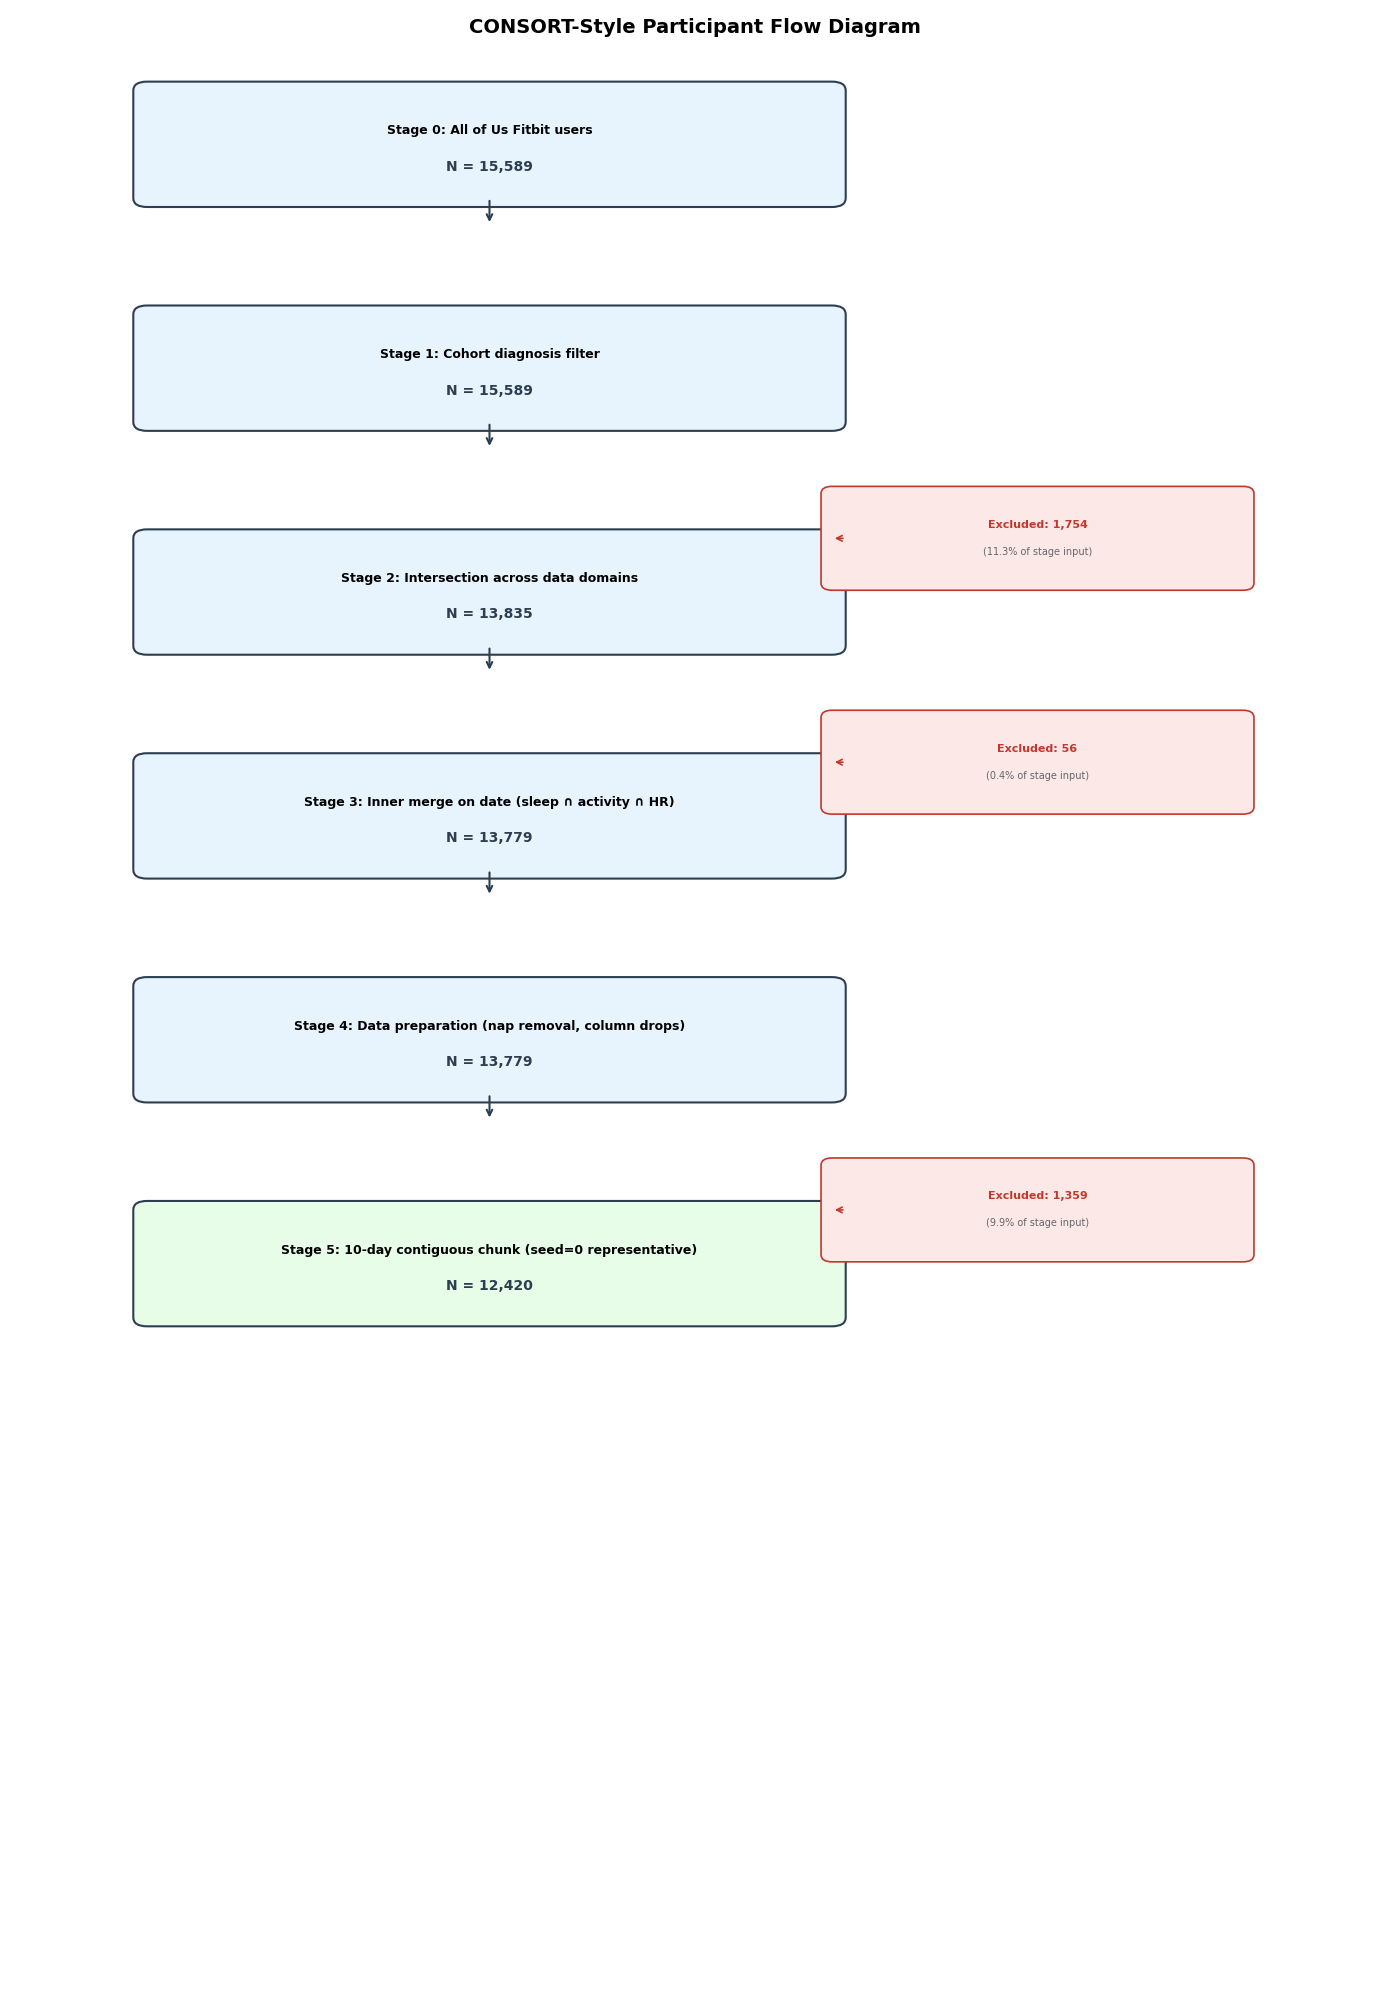

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_consort_flow_diagram(flow_df, n_stage0, save_path='consort_flow_diagram'):
    """
    Draw a CONSORT-style flow diagram using matplotlib.
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 20))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 22)
    ax.axis('off')

    # Colors
    box_color = '#E8F4FD'
    excl_color = '#FDE8E8'
    final_color = '#E8FDE8'
    border_color = '#2C3E50'
    excl_border = '#C0392B'

    # Box dimensions
    box_w = 5.0
    box_h = 1.2
    excl_w = 3.0
    excl_h = 1.0

    # Center x for main flow
    cx = 3.5
    # x for exclusion boxes (right side)
    ex = 7.5

    stages = flow_df.to_dict('records')

    y_positions = [20.5, 18.0, 15.5, 13.0, 10.5, 8.0]
    
    for i, (stage, y) in enumerate(zip(stages, y_positions)):
        # Determine box color
        if i == len(stages) - 1:
            fc = final_color
        else:
            fc = box_color

        # Main box
        rect = patches.FancyBboxPatch(
            (cx - box_w/2, y - box_h/2), box_w, box_h,
            boxstyle="round,pad=0.1",
            facecolor=fc, edgecolor=border_color, linewidth=1.5
        )
        ax.add_patch(rect)

        # Main box text
        ax.text(cx, y + 0.15, f"Stage {int(stage['Stage'])}: {stage['Description']}",
                ha='center', va='center', fontsize=9, fontweight='bold', wrap=True)
        ax.text(cx, y - 0.25, f"N = {int(stage['N_Out']):,}",
                ha='center', va='center', fontsize=10, fontweight='bold', color='#2C3E50')

        # Arrow to next stage
        if i < len(stages) - 1:
            ax.annotate('', xy=(cx, y - box_h/2 - 0.3), xytext=(cx, y - box_h/2),
                        arrowprops=dict(arrowstyle='->', color=border_color, lw=1.5))

        # Exclusion box (for stages 1-5)
        if i > 0 and stage['N_Excluded'] > 0:
            ey = y + 0.6  # slightly above the main box

            # Arrow from between stages to exclusion box
            ax.annotate('', xy=(ex - excl_w/2, ey), xytext=(cx + box_w/2 + 0.1, ey),
                        arrowprops=dict(arrowstyle='->', color=excl_border, lw=1.2))

            # Exclusion box
            excl_rect = patches.FancyBboxPatch(
                (ex - excl_w/2, ey - excl_h/2), excl_w, excl_h,
                boxstyle="round,pad=0.08",
                facecolor=excl_color, edgecolor=excl_border, linewidth=1.2
            )
            ax.add_patch(excl_rect)

            ax.text(ex, ey + 0.15, f"Excluded: {int(stage['N_Excluded']):,}",
                    ha='center', va='center', fontsize=8, fontweight='bold', color=excl_border)
            ax.text(ex, ey - 0.15, f"({stage['Pct_Excluded']:.1f}% of stage input)",
                    ha='center', va='center', fontsize=7, color='#666666')

    # Title
    ax.text(5, 21.8, 'CONSORT-Style Participant Flow Diagram',
            ha='center', va='center', fontsize=14, fontweight='bold')

    plt.tight_layout()
    fig.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(f'{save_path}.svg', bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}.png and {save_path}.svg")
    plt.show()

draw_consort_flow_diagram(flow_df, n_stage0)

---
---

# Per-Cohort Breakdown

Selection bias could differentially affect one cohort more than another. We repeat the key comparisons broken down by cohort.

## Per-Cohort Exclusion Counts at Stage 2 (Intersection)

In [41]:
per_cohort_results_stage2 = []

for cohort_name in cohorts:
    union_ids = cohort_union_ids[cohort_name]
    intersection_ids_cohort = cohort_intersection_ids[cohort_name]

    # Get demographics for this cohort's union
    demo_cohort = all_fitbit_demo[all_fitbit_demo['person_id'].isin(union_ids)]

    if len(union_ids - intersection_ids_cohort) < 5:
        print(f"\n{cohort_name}: Too few excluded ({len(union_ids - intersection_ids_cohort)}) for meaningful comparison.")
        continue

    results, _ = compare_groups(
        demo_cohort,
        intersection_ids_cohort,
        f"Stage 2 Intersection — {cohort_name}"
    )
    per_cohort_results_stage2.append(results)

if per_cohort_results_stage2:
    per_cohort_stage2_df = pd.concat(per_cohort_results_stage2, ignore_index=True)


Stage: Stage 2 Intersection — anxiety
  Included: 2,299  |  Excluded: 257

Variable             Test                Statistic      p-value  Effect Size   Flag
----------------------------------------------------------------------------------
gender               chi-squared              1.39       0.4999       0.0233       
race                 chi-squared              6.16       0.6288       0.0491       
ethnicity            chi-squared              3.22       0.5212       0.0355       
sex_at_birth         chi-squared              3.25       0.3547       0.0357       
age                  Mann-Whitney U      264362.50       0.0056      -0.1850     ⚠️

  Distribution — gender:
    Female                                   Excluded:  72.0%   Included:  75.3%
    Male                                     Excluded:  22.6%   Included:  19.8%
    Not man only, not woman only, prefer not to answer, or skipped Excluded:   5.4%   Included:   4.8%

  Distribution — race:
    Another single pop

## Per-Cohort Stage 5 (Chunk Selection) — Label Distribution

In [42]:
# Check whether the exclusion at Stage 5 differentially affects the 3 label groups
print("Label distribution in Stage 5 included vs. excluded (seed=0):\n")

labels_with_inclusion = labels.copy()
labels_with_inclusion['included_stage5'] = labels_with_inclusion.index.isin(ids_after_chunk_seed0)

for col in ['Anxiety disorder', 'Depressive disorder', 'No disorder']:
    inc = labels_with_inclusion[labels_with_inclusion['included_stage5']]
    exc = labels_with_inclusion[~labels_with_inclusion['included_stage5']]

    inc_pct = inc[col].mean() * 100
    exc_pct = exc[col].mean() * 100

    # Two-proportion z-test
    n1, n2 = len(inc), len(exc)
    p1, p2 = inc[col].mean(), exc[col].mean()
    p_pooled = (inc[col].sum() + exc[col].sum()) / (n1 + n2)
    if p_pooled > 0 and p_pooled < 1:
        se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
        z = (p1 - p2) / se if se > 0 else 0
        p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    else:
        z, p_val = 0, 1.0

    flag = "⚠️" if abs(p1 - p2) > 0.03 else ""  # flag if >3 percentage point difference
    print(f"  {col:<25}: Included = {inc_pct:5.1f}%  |  Excluded = {exc_pct:5.1f}%  |  "
          f"Diff = {(inc_pct - exc_pct):+5.1f}pp  |  z = {z:6.2f}  |  p = {p_val:.4f}  {flag}")

Label distribution in Stage 5 included vs. excluded (seed=0):

  Anxiety disorder         : Included =  16.6%  |  Excluded =  16.9%  |  Diff =  -0.3pp  |  z =  -0.29  |  p = 0.7708  
  Depressive disorder      : Included =  15.7%  |  Excluded =  16.3%  |  Diff =  -0.7pp  |  z =  -0.65  |  p = 0.5151  
  No disorder              : Included =  78.4%  |  Excluded =  77.5%  |  Diff =  +0.9pp  |  z =   0.80  |  p = 0.4235  


## Stage 5 Variability Across Seeds — Per-Cohort


In [43]:
# Track label distribution across all 100 seeds
print("Label distribution variability across 100 seeds at Stage 5:\n")

seed_label_stats = {col: [] for col in ['Anxiety disorder', 'Depressive disorder', 'No disorder']}

for r in stage5_results:
    inc_labels = labels.loc[labels.index.isin(r['included_ids'])]
    for col in seed_label_stats:
        seed_label_stats[col].append(inc_labels[col].mean() * 100)

print(f"{'Label':<25} {'Mean %':>8} {'Std %':>8} {'Min %':>8} {'Max %':>8}")
print("-" * 60)
for col, vals in seed_label_stats.items():
    print(f"{col:<25} {np.mean(vals):>8.2f} {np.std(vals):>8.2f} {np.min(vals):>8.2f} {np.max(vals):>8.2f}")

print("\n(Stable percentages across seeds indicate that the stochastic chunk selection")
print(" does not systematically favor or disfavor any particular label group.)")

Label distribution variability across 100 seeds at Stage 5:

Label                       Mean %    Std %    Min %    Max %
------------------------------------------------------------
Anxiety disorder             16.54     0.05    16.41    16.63
Depressive disorder          15.68     0.05    15.58    15.82
No disorder                  78.38     0.05    78.26    78.51

(Stable percentages across seeds indicate that the stochastic chunk selection
 does not systematically favor or disfavor any particular label group.)


---
---

# Summary

In [44]:
# Print a clean summary for manuscript preparation
print("=" * 90)
print("SUMMARY OF SELECTION BIAS ASSESSMENT")
print("=" * 90)

print(f"\n1. EXCLUSION CASCADE:")
print(f"   Total Fitbit participants (Stage 0):  {n_stage0:>8,}")
print(f"   Final analysis sample (Stage 5):      {n_stage5:>8,}")
print(f"   Overall excluded:                     {n_stage0 - n_stage5:>8,} ({(n_stage0 - n_stage5)/n_stage0*100:.1f}%)")

print(f"\n2. LARGEST EXCLUSION STAGES:")
for _, row in flow_df[flow_df['N_Excluded'] > 0].sort_values('N_Excluded', ascending=False).head(3).iterrows():
    print(f"   Stage {int(row['Stage'])}: {row['Description']:<50} — {int(row['N_Excluded']):>6,} excluded ({row['Pct_Excluded']:.1f}%)")

print(f"\n3. DEMOGRAPHIC IMBALANCES:")
flagged = all_comparison_results[all_comparison_results['flag'] == True]
if len(flagged) > 0:
    for _, row in flagged.iterrows():
        print(f"   ⚠️  {row['stage']}: {row['variable']} — {row['effect_size_name']} = {row['effect_size']:.3f}")
else:
    print(f"   ✅ No meaningful demographic imbalances detected (all effect sizes ≤ 0.1)")

print(f"\n4. FITBIT FEATURE IMBALANCES (Stage 5):")
flagged_features = feature_comparison_df[feature_comparison_df['flag'] == True]
if len(flagged_features) > 0:
    print(f"   ⚠️  {len(flagged_features)} features with |SMD| > 0.1:")
    for _, row in flagged_features.iterrows():
        print(f"      {row['feature']:<35} SMD = {row['smd']:+.3f}")
else:
    print(f"   ✅ No meaningful feature imbalances detected")

print(f"\n5. STAGE 5 STOCHASTIC VARIABILITY:")
print(f"   Inclusion count across 100 seeds: {np.mean(stage5_inclusion_counts):.0f} ± {np.std(stage5_inclusion_counts):.1f}")
print(f"   Range: [{np.min(stage5_inclusion_counts):,}, {np.max(stage5_inclusion_counts):,}]")

print("\n" + "=" * 90)

SUMMARY OF SELECTION BIAS ASSESSMENT

1. EXCLUSION CASCADE:
   Total Fitbit participants (Stage 0):    15,589
   Final analysis sample (Stage 5):        12,420
   Overall excluded:                        3,169 (20.3%)

2. LARGEST EXCLUSION STAGES:
   Stage 2: Intersection across data domains                   —  1,754 excluded (11.3%)
   Stage 5: 10-day contiguous chunk (seed=0 representative)    —  1,359 excluded (9.9%)
   Stage 3: Inner merge on date (sleep ∩ activity ∩ HR)        —     56 excluded (0.4%)

3. DEMOGRAPHIC IMBALANCES:
   ⚠️  Stage 2: Intersection Filter: age — Cohen's d (SMD) = -0.122
   ⚠️  Stage 3: Inner Merge on Date: age — Cohen's d (SMD) = 0.136

4. FITBIT FEATURE IMBALANCES (Stage 5):
   ⚠️  16 features with |SMD| > 0.1:
      total_days                          SMD = +1.599
      mean_steps                          SMD = +0.219
      mean_sedentary_minutes              SMD = -1.356
      mean_lightly_active_minutes         SMD = +0.462
      mean_fairly_active_m

NOTE: See Section 4.0.1 and 4.0.2 for Stage 5 interpretation details

---
---

# Export Results

In [45]:
# Create output directory
import os
os.makedirs('revision_outputs', exist_ok=True)

# Save exclusion flow table
flow_df.to_csv('revision_outputs/consort_flow_counts.csv', index=False)
print("Saved: revision_outputs/consort_flow_counts.csv")

# Save demographic comparison results
all_comparison_results.to_csv('revision_outputs/selection_bias_demographic_comparisons.csv', index=False)
print("Saved: revision_outputs/selection_bias_demographic_comparisons.csv")

# Save Fitbit feature comparison results
feature_comparison_df.to_csv('revision_outputs/selection_bias_feature_comparisons.csv', index=False)
print("Saved: revision_outputs/selection_bias_feature_comparisons.csv")

# Save Stage 5 variability across seeds
stage5_var_df = pd.DataFrame({
    'seed_offset': [r['seed_offset'] for r in stage5_results],
    'n_included': [r['n_included'] for r in stage5_results],
    'n_excluded': [r['n_excluded'] for r in stage5_results],
})
stage5_var_df.to_csv('revision_outputs/stage5_variability_across_seeds.csv', index=False)
print("Saved: revision_outputs/stage5_variability_across_seeds.csv")

# Copy CONSORT diagram
import shutil
for ext in ['png', 'svg']:
    src = f'consort_flow_diagram.{ext}'
    dst = f'revision_outputs/consort_flow_diagram.{ext}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Saved: {dst}")

print("\nAll outputs saved to revision_outputs/")

Saved: revision_outputs/consort_flow_counts.csv
Saved: revision_outputs/selection_bias_demographic_comparisons.csv
Saved: revision_outputs/selection_bias_feature_comparisons.csv
Saved: revision_outputs/stage5_variability_across_seeds.csv
Saved: revision_outputs/consort_flow_diagram.png
Saved: revision_outputs/consort_flow_diagram.svg

All outputs saved to revision_outputs/


In [46]:
# Upload to GCS
!gsutil -m cp revision_outputs/* {my_bucket}/data/revision/
print("\nAll outputs uploaded to GCS: {my_bucket}/data/revision/")

Copying file://revision_outputs/stage5_variability_across_seeds.csv [Content-Type=text/csv]...
Copying file://revision_outputs/consort_flow_diagram.png [Content-Type=image/png]...
Copying file://revision_outputs/selection_bias_feature_comparisons.csv [Content-Type=text/csv]...
Copying file://revision_outputs/selection_bias_demographic_comparisons.csv [Content-Type=text/csv]...
Copying file://revision_outputs/consort_flow_diagram.svg [Content-Type=image/svg+xml]...
Copying file://revision_outputs/consort_flow_counts.csv [Content-Type=text/csv]...
- [6/6 files][409.8 KiB/409.8 KiB] 100% Done                                    
Operation completed over 6 objects/409.8 KiB.                                    

All outputs uploaded to GCS: {my_bucket}/data/revision/


In [47]:
# List uploaded files
!gsutil ls {my_bucket}/data/revision/

gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/consort_flow_counts.csv
gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/consort_flow_diagram.png
gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/consort_flow_diagram.svg
gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/selection_bias_demographic_comparisons.csv
gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/selection_bias_feature_comparisons.csv
gs://fc-secure-9f8bced0-e1d4-4533-88eb-61db3f3763da/data/revision/stage5_variability_across_seeds.csv


---
---

# End of Notebook

All selection bias assessment outputs have been saved locally and uploaded to GCS.

**Files produced:**
- `consort_flow_counts.csv` — Exclusion counts at each pipeline stage
- `selection_bias_demographic_comparisons.csv` — Statistical tests comparing included vs. excluded demographics
- `selection_bias_feature_comparisons.csv` — Fitbit feature comparisons at Stage 5
- `stage5_variability_across_seeds.csv` — Inclusion count variability across 100 experiment seeds
- `consort_flow_diagram.png` / `.svg` — Publication-quality flow diagram

---

---